# 02 — Build network: tau sweep, manual threshold, Infomap clustering

**Input:**
- `outputs/01_filtered_betas/betas_rho0.30.tsv` — filtered betas from notebook 01

**Output:**
- `outputs/02_network/codelength_savings_vs_tau.csv` — sweep results
- `outputs/02_network/codelength_savings_vs_tau.png` — sweep plot
- `outputs/02_network/network.gexf` — pruned network
- `outputs/02_network/module_assignments.csv` — CpG → Module table
- `outputs/02_network/network_summary.txt` — summary

**Workflow (important: two-step with manual choice):**
1. Compute full correlation matrix
2. Sweep tau, plot codelength savings vs tau
3. **Look at the plot, pick a tau manually** — the best tau by metric alone is often not ideal (can over-segment or leave too many singletons)
4. Enter chosen tau in the last cell
5. Build network + run Infomap with that tau, save GEXF and modules

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import infomap
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "Arial", "font.size": 12,
    "axes.labelsize": 12, "figure.facecolor": "white",
    "savefig.bbox": "tight", "savefig.dpi": 300,
})

# ── Config ────────────────────────────────────────────────────────
FILTERED_BETAS = "outputs/01_filtered_betas/BetaMatrix_0.35.tsv"

OUT_DIR = Path("outputs/02_network")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Tau from bootstrap
TAU = 0.65

## Load filtered betas → correlation matrix

In [2]:
print(f"Loading {FILTERED_BETAS} ...")
df_raw = pd.read_csv(FILTERED_BETAS, sep="\t", low_memory=False, index_col=0)
print(f"  Raw shape: {df_raw.shape}")

df = df_raw.copy()
# Drop Age column if present
if "Age" in df.columns:
    df = df.drop(columns=["Age"])

# Orient so CpGs are columns (we compute CpG × CpG correlation)
# If index looks like CpGs, transpose
if pd.Series(df.index.astype(str)).head(20).str.startswith("cg").sum() > 10:
    print("  CpGs in index -> transposing (need CpGs as columns)")
    df = df.T

print(f"  After orientation: {df.shape[0]} samples × {df.shape[1]:,} CpGs")

# Ensure numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Fill NaNs with per-CpG mean
n_na = df.isna().sum().sum()
if n_na > 0:
    print(f"  Filling {n_na:,} NaN values with per-CpG mean")
    df = df.fillna(df.mean(numeric_only=True))

Loading outputs/01_filtered_betas/BetaMatrix_0.35.tsv ...
  Raw shape: (7328, 1917)
  CpGs in index -> transposing (need CpGs as columns)
  After orientation: 1917 samples × 7,328 CpGs


Computing CpG × CpG Spearman correlation (7,328 × 7,328) ...
  Correlation matrix shape: (7328, 7328)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

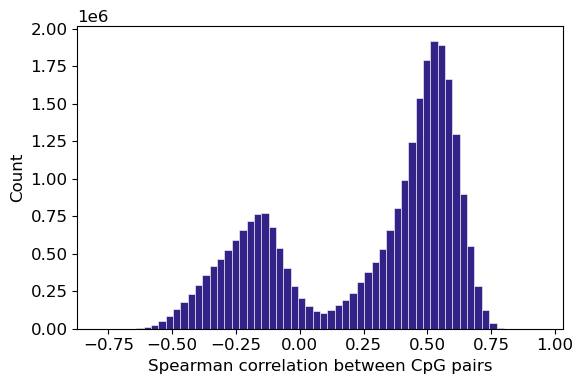

In [3]:
print(f"Computing CpG × CpG Spearman correlation ({df.shape[1]:,} × {df.shape[1]:,}) ...")
dfCorr = df.corr(method="spearman")
print(f"  Correlation matrix shape: {dfCorr.shape}")

# Histogram of off-diagonal correlations
off = dfCorr.values[np.triu_indices_from(dfCorr.values, k=1)]
plt.figure(figsize=(6, 4))
plt.hist(off, bins=60, color="#332288", edgecolor="white", linewidth=0.4)
plt.xlabel("Spearman correlation between CpG pairs")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Build the network from tau from the bootsrap sweep



In [4]:
Sigma = dfCorr.values
adj = (Sigma * ((Sigma) > TAU))
unw = (adj > 0).astype(int)
np.fill_diagonal(unw, 0)

G = nx.from_numpy_array(unw)
# Rename nodes to CpG IDs
mapping = {i: str(cg) for i, cg in enumerate(dfCorr.columns)}
G = nx.relabel_nodes(G, mapping)

print(f"  Network: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
# Basic stats
if G.number_of_edges() > 0:
    degrees = [d for _, d in G.degree()]
    print(f"  Degree: min={min(degrees)}, max={max(degrees)}, mean={np.mean(degrees):.2f}")
    n_isolated = sum(1 for _, d in G.degree() if d == 0)
    print(f"  Isolated nodes: {n_isolated:,}")

  Network: 7,328 nodes, 1,140,966 edges
  Degree: min=0, max=2542, mean=311.40
  Isolated nodes: 2,965


In [5]:
# Run Infomap on chosen tau's network
print("Running Infomap ...")
im = infomap.Infomap(two_level=False, regularized=False, silent=False)
im.add_networkx_graph(G)
im.run()

print(f"\n  Codelength savings: {im.relative_codelength_savings:.4f}")
print(f"  Number of top modules: {im.num_top_modules}")

# Extract module assignments
# Infomap uses integer node IDs in its internal tree; map back to CpG names
node_list = list(G.nodes())
modules = {}
for node_id, module_id in im.modules:
    if 0 <= node_id < len(node_list):
        modules[node_list[node_id]] = int(module_id)

# Any nodes not assigned? Give them their own module (singletons)
max_mod = max(modules.values()) if modules else 0
next_id = max_mod + 1
for n in G.nodes():
    if n not in modules:
        modules[n] = next_id
        next_id += 1

# Attach as node attribute (for GEXF)
nx.set_node_attributes(G, modules, "module")

# Quick summary
from collections import Counter
mod_sizes = Counter(modules.values())
n_large = sum(1 for s in mod_sizes.values() if s >= 20)
n_small = sum(1 for s in mod_sizes.values() if 2 <= s < 20)
n_sing = sum(1 for s in mod_sizes.values() if s == 1)
print(f"\n  Modules: {len(mod_sizes)} total")
print(f"    Large (≥20 nodes): {n_large}")
print(f"    Small (2-19 nodes): {n_small}")
print(f"    Singletons: {n_sing}")

Running Infomap ...
  Infomap v2.9.0 starts at 2026-05-06
  Codelength savings: 0.0023
  Number of top modules: 3107
 12:58:01
  -> Input network: 
  -> No file output!
  OpenMP 201511 detected with 8 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 7328 nodes and 1140966 links...
  -> One-level codelength: 11.0310274

Trial 1/1 starting at 2026-05-06 12:58:01
Two-level compression: 0.22% 5.1e-05% 
Partitioned to codelength 0.000949589248 + 11.0054009 = 11.00635048 in 3154 (190 non-trivial) modules.
Super-level compression: 0.000966165845% to codelength 11.00624414 in 3107 top modules.

Recursive sub-structure compression: 0.0293090034% 0.00148341014% 0% . Found 4 levels with codelength 11.00609423

=> Trial 1/1 finished in 3.02202427s with codel
  Modules: 3107 total
    Large (≥20

## Save outputs

In [6]:
# GEXF
gexf_path = OUT_DIR / "network.gexf"
nx.write_gexf(G, str(gexf_path))
print(f"  Saved: {gexf_path}")

# Module assignments CSV
df_mod = pd.DataFrame(
    [(cpg, m) for cpg, m in modules.items()],
    columns=["CpG", "Module"],
)
df_mod = df_mod.sort_values(["Module", "CpG"]).reset_index(drop=True)
mod_path = OUT_DIR / "module_assignments.csv"
df_mod.to_csv(mod_path, index=False)
print(f"  Saved: {mod_path}")

# Summary
summary = f"""Network build summary
======================
Input:  {FILTERED_BETAS}
Tau (chosen): {TAU}
Nodes: {G.number_of_nodes():,}
Edges: {G.number_of_edges():,}
Total modules: {len(mod_sizes)}
  Large (>=20 nodes): {n_large}
  Small (2-19 nodes): {n_small}
  Singletons: {n_sing}
"""
with open(OUT_DIR / "network_summary.txt", "w") as f:
    f.write(summary)
print(summary)

  Saved: outputs/02_network/network.gexf
  Saved: outputs/02_network/module_assignments.csv
Network build summary
Input:  outputs/01_filtered_betas/BetaMatrix_0.35.tsv
Tau (chosen): 0.65
Nodes: 7,328
Edges: 1,140,966
Total modules: 3107
  Large (>=20 nodes): 4
  Small (2-19 nodes): 139
  Singletons: 2964

